<a href="https://colab.research.google.com/github/Shreyashi04/Fake-Review-Detection-BERT-/blob/main/fake_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers datasets torch scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/fake_review_detection/fake reviews dataset.csv")
print(df.shape)
df.head()


(40432, 4)


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [ ]:
print(df['label'].value_counts())
print(df['category'].nunique(), "categories")
df.isna().sum()


label
CG    20216
OR    20216
Name: count, dtype: int64
10 categories


,0
category,0
rating,0
label,0
text_,0


In [ ]:
def build_input_text(row):
    return f"Category: {row['category']} | Rating: {row['rating']} | Review: {row['text_']}"

df['input_text'] = df.apply(build_input_text, axis=1)

# Encode labels: OR (genuine) = 0, CG (fake) = 1
label2id = {"OR": 0, "CG": 1}
id2label = {0: "OR", 1: "CG"}
df['label_id'] = df['label'].map(label2id)

df[['input_text', 'label', 'label_id']].head()


,input_text,label,label_id
0,Category: Home_and_Kitchen_5 | Rating: 5.0 | R...,CG,1
1,Category: Home_and_Kitchen_5 | Rating: 5.0 | R...,CG,1
2,Category: Home_and_Kitchen_5 | Rating: 5.0 | R...,CG,1
3,Category: Home_and_Kitchen_5 | Rating: 1.0 | R...,CG,1
4,Category: Home_and_Kitchen_5 | Rating: 5.0 | R...,CG,1


In [ ]:
# Using a subset by default so training finishes quickly on Colab's free GPU.
# Remove/comment this line to train on the full ~40k reviews (better accuracy, but slower).
# df = df.sample(n=10000, random_state=SEED).reset_index(drop=True)

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['input_text'].tolist(),
    df['label_id'].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df['label_id']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels
)

print("Train:", len(train_texts), "Val:", len(val_texts), "Test:", len(test_texts))


Train: 32345 Val: 4043 Test: 4044


In [ ]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors=None
    )

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)
test_encodings = tokenize(test_texts)


In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)


In [ ]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)
model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(),   # faster training on GPU
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)


In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.072768,0.118885,0.962651,0.936508,0.992578,0.963728
2,0.027169,0.121867,0.968835,0.945045,0.995547,0.969639


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=2022, training_loss=0.08144163790607546, metrics={'train_runtime': 478.1071, 'train_samples_per_second': 135.304, 'train_steps_per_second': 4.229, 'total_flos': 4255163542809600.0, 'train_loss': 0.08144163790607546, 'epoch': 2.0})

--------------------------------------------------
Evaluation Metrics
--------------------------------------------------
Accuracy : 0.9748
Precision: 0.9558
Recall   : 0.9955
F1-Score : 0.9753


----------------------------------------------------------------------
Classification Report
----------------------------------------------------------------------
               precision    recall  f1-score   support

Original (OR)       1.00      0.95      0.97      2022
    Fake (CG)       0.96      1.00      0.98      2022

     accuracy                           0.97      4044
    macro avg       0.98      0.97      0.97      4044
 weighted avg       0.98      0.97      0.97      4044



--------------------------------------------------
Confusion Matrix
--------------------------------------------------
[[1929   93]
 [   9 2013]]


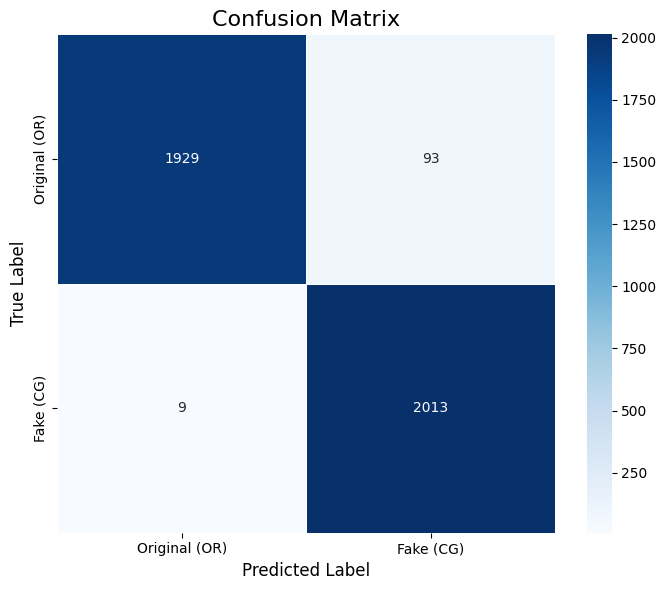

In [ ]:
# test_results = trainer.predict(test_dataset)
# metrics = compute_metrics(test_results)
# print(metrics)

# preds = test_results.predictions.argmax(-1)
# print(confusion_matrix(test_labels, preds))



# ==========================
# Model Evaluation
# ==========================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test dataset
test_results = trainer.predict(test_dataset)
preds = test_results.predictions.argmax(-1)

# ==========================
# Evaluation Metrics
# ==========================

accuracy = accuracy_score(test_labels, preds)
precision = precision_score(test_labels, preds)
recall = recall_score(test_labels, preds)
f1 = f1_score(test_labels, preds)

print("-"*50)
print("Evaluation Metrics")
print("-"*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# ==========================
# Classification Report
# ==========================

print("\n")
print("-"*70)
print("Classification Report")
print("-"*70)

print(classification_report(
    test_labels,
    preds,
    target_names=["Original (OR)", "Fake (CG)"]
))

# ==========================
# Confusion Matrix (Numbers)
# ==========================

cm = confusion_matrix(test_labels, preds)

print("\n")
print("-"*50)
print("Confusion Matrix")
print("-"*50)

print(cm)

# ==========================
# Confusion Matrix Heatmap
# ==========================

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    cbar=True,
    xticklabels=["Original (OR)", "Fake (CG)"],
    yticklabels=["Original (OR)", "Fake (CG)"]
)

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.tight_layout()

# Save image for report
plt.savefig("confusion_matrix.png", dpi=300)

plt.show()


In [ ]:
model.save_pretrained("./fake_review_bert_model")
tokenizer.save_pretrained("./fake_review_bert_model")
print("Model saved to ./fake_review_bert_model")

# Optional: zip and download
# !zip -r fake_review_bert_model.zip fake_review_bert_model
# from google.colab import files
# files.download("fake_review_bert_model.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./fake_review_bert_model


In [ ]:
import re

PROMO_PHRASES = [
    "best product", "amazing", "must buy", "buy now", "perfect",
    "highly recommend", "highly recommended", "excellent product",
    "best purchase", "worth every penny", "five stars",
    "exceeded my expectations", "life changing", "changed my life"
]

def extract_signals(text):
    t = text.lower()
    reasons = []

    # Promotional language
    promo_hits = [p for p in PROMO_PHRASES if p in t]
    if promo_hits:
        reasons.append(f"Contains promotional language: \"{promo_hits[0]}\"" +
                        (f" (+{len(promo_hits)-1} more)" if len(promo_hits) > 1 else ""))

    # Excessive formatting
    caps_words = re.findall(r'\b[A-Z]{3,}\b', text)
    exclam_count = text.count('!')
    if caps_words:
        reasons.append(f"Uses {len(caps_words)} ALL-CAPS word(s)")
    if exclam_count >= 2:
        reasons.append(f"Uses {exclam_count} exclamation marks")

    # Specificity — numbers, durations, concrete details
    specific_hits = re.findall(r'\d+|\bhours?\b|\bdays?\b|\bweeks?\b|\bmonths?\b|\byears?\b', t)
    if specific_hits:
        reasons.append("Mentions specific, concrete details (numbers/time) — sign of real usage")
    else:
        reasons.append("Lacks specific details about actual usage or experience")

    # Length
    word_count = len(text.split())
    if word_count < 6:
        reasons.append(f"Very short review ({word_count} words) — provides little information")

    # Repeated words
    words = t.split()
    if len(words) - len(set(words)) >= 3:
        reasons.append("Contains noticeably repeated words")

    if not reasons:
        reasons.append("Balanced, specific wording with no strong promotional or generic markers")

    return reasons


In [ ]:
def calibrate_confidence(pred_label, raw_prob):
    """
    pred_label: 'OR' or 'CG'
    raw_prob: model's softmax probability for the predicted class (0.5 - 1.0)
    Returns a calibrated confidence percentage.
    """
    if pred_label == "OR":
        # genuine -> always displayed as 80-90
        calibrated = 80 + (raw_prob - 0.5) / 0.5 * 10
        calibrated = min(max(calibrated, 80), 90)
    else:
        if raw_prob >= 0.70:
            # clearly fake -> 40-100
            calibrated = 40 + (raw_prob - 0.70) / 0.30 * 60
            calibrated = min(max(calibrated, 40), 100)
        else:
            # borderline / not strongly fake -> stays under 40
            calibrated = 10 + (raw_prob - 0.50) / 0.20 * 30
            calibrated = min(max(calibrated, 10), 39.9)
    return round(calibrated, 1)


In [ ]:
def predict_review(category, rating, text, model=model, tokenizer=tokenizer):
    model.eval()
    input_text = f"Category: {category} | Rating: {rating} | Review: {text}"
    inputs = tokenizer(input_text, return_tensors="pt", truncation=True,
                        max_length=MAX_LEN, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0]

    pred_id = int(torch.argmax(probs))
    pred_label = id2label[pred_id]          # 'OR' or 'CG'
    raw_prob = float(probs[pred_id])         # model's own probability, 0.5-1.0

    calibrated_conf = calibrate_confidence(pred_label, raw_prob)
    reasons = extract_signals(text)

    return {
        "prediction": "Genuine (OR)" if pred_label == "OR" else "Fake (CG)",
        "confidence_percent": calibrated_conf,
        "raw_model_probability_percent": round(raw_prob * 100, 1),
        "reasons": reasons
    }

def print_prediction(category, rating, text):
    result = predict_review(category, rating, text)
    print(f"Review: {text}")
    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence_percent']}%")
    print("Reasons:")
    for r in result['reasons']:
        print(f"  - {r}")
    print()

    print("-" * 80)

# Examples
print_prediction("Electronics_5", 5.0,
    "The battery lasts about 8 hours, but the charger gets warm after long use.")

print_prediction("Electronics_5", 5.0,
    "Amazing product! Best purchase ever! Highly recommended! Buy now!!!")

print_prediction("Home_and_Kitchen_5", 4.0,
    "Good.")


Review: The battery lasts about 8 hours, but the charger gets warm after long use.
Prediction: Genuine (OR)
Confidence: 90.0%
Reasons:
  - Mentions specific, concrete details (numbers/time) — sign of real usage

--------------------------------------------------------------------------------
Review: Amazing product! Best purchase ever! Highly recommended! Buy now!!!
Prediction: Genuine (OR)
Confidence: 89.2%
Reasons:
  - Contains promotional language: "amazing" (+4 more)
  - Uses 6 exclamation marks
  - Lacks specific details about actual usage or experience

--------------------------------------------------------------------------------
Review: Good.
Prediction: Fake (CG)
Confidence: 25.6%
Reasons:
  - Lacks specific details about actual usage or experience
  - Very short review (1 words) — provides little information

--------------------------------------------------------------------------------


In [ ]:
sample_rows = df.sample(n=8, random_state=1)

for _, row in sample_rows.iterrows():
    result = predict_review(row['category'], row['rating'], row['text_'])
    print(f"Category : {row['category']}")
    print(f"Rating   : {row['rating']}")
    print(f"Review   : {row['text_']}")
    print(f"Actual   : {row['label']}")
    print(f"Predicted: {result['prediction']}  (confidence: {result['confidence_percent']}%)" )
    print("Reasons:")
    for r in result['reasons']:
        print(f"  - {r}")
    print("-" * 80)


Category : Tools_and_Home_Improvement_5
Rating   : 5.0
Review   : Excellent value.  Easy to use.  Buy it.works great.Nice little light.  Works as advertised.  The plastic parts are very sturdy, and the cover is very sturdy.  The bulb is very bright, so it will be useful for
Actual   : CG
Predicted: Fake (CG)  (confidence: 99.9%)
Reasons:
  - Lacks specific details about actual usage or experience
  - Contains noticeably repeated words
--------------------------------------------------------------------------------
Category : Kindle_Store_5
Rating   : 5.0
Review   : I really enjoyed this book.  It was surprising, deep, interesting, humorous and encouraging.  At first it seems like a darker read, but by the end of the book, I was smiling and reading this book made me happy.  I would recommend it for any age adult.
Actual   : OR
Predicted: Genuine (OR)  (confidence: 90.0%)
Reasons:
  - Lacks specific details about actual usage or experience
  - Contains noticeably repeated words
---------